# 14. Case Study: Credit Risk, End to End

One problem, start to finish, applying the whole book. New dataset, so nothing here is a rerun.

A bank wants to predict which loan applicants will default. The dataset is the **German credit** data: 1000 applications, 20 features, and an outcome of `good` or `bad`. It comes with something most datasets do not — a documented statement of what mistakes cost.

> Classifying a customer as good when they are bad is **five times** as expensive as classifying a customer as bad when they are good.

That single sentence changes the entire analysis, and it is why this is the closing chapter. Everything the book has said about choosing metrics before looking at results, about baselines, about thresholds being policy rather than parameters, becomes concrete when the cost of being wrong is written down.

**Prerequisites:** the rest of the book.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tuiml
from tuiml.datasets import load_credit
from tuiml.workflow import Workflow
from tuiml.preprocessing import StandardScaler, SMOTESampler
from tuiml.evaluation import (
    train_test_split, StratifiedKFold, cross_val_score,
    confusion_matrix, accuracy_score, recall_score, precision_score,
)

COST_FALSE_NEGATIVE = 5    # approved a loan that defaulted
COST_FALSE_POSITIVE = 1    # refused a loan that would have been repaid

## 14.1 Hold out the test set before anything else

Chapter 7 said: use search to choose, and a set touched once to report. That set has to be removed *now*, before we have looked at anything, or the discipline is unenforceable.

In [2]:
data = load_credit()
X, y = data.X, data.y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"train: {X_train.shape}   test: {X_test.shape}  (set aside, untouched until 14.7)")

train: (750, 20)   test: (250, 20)  (set aside, untouched until 14.7)


## 14.2 Profile — the training half only

In [3]:
print("features:", len(data.feature_names))
print(", ".join(data.feature_names))
print()

classes, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(classes, counts):
    print(f"  {cls} = {data.target_names[cls]:5s} {count:4d}  ({count / len(y_train):.1%})")

print()
print("missing values:", int(np.isnan(X_train).sum()))
distinct = [len(np.unique(X_train[:, i])) for i in range(X_train.shape[1])]
print("likely categorical (<=10 distinct):",
      sum(1 for d in distinct if d <= 10), "of", len(distinct))

features: 20
checking_status, duration, credit_history, purpose, credit_amount, savings_status, employment, installment_commitment, personal_status, other_parties, residence_since, property_magnitude, age, other_payment_plans, housing, existing_credits, job, num_dependents, own_telephone, foreign_worker

  0 = good   525  (70.0%)
  1 = bad    225  (30.0%)

missing values: 0
likely categorical (<=10 distinct): 17 of 20


Three facts to carry forward.

**70/30 imbalance**, with the expensive class being the rare one — the same shape as chapter 6, but now the asymmetry is quantified rather than assumed.

**No missing values.** Unusually clean; chapter 3's work is not needed here.

**Mostly categorical**, already integer-encoded. Chapter 3 warned that ordinal encoding implies an ordering that may not exist — `purpose = 7` is not more than `purpose = 3`. Trees handle this by splitting repeatedly; a linear model will read the codes as magnitudes. Worth remembering when we interpret the bake-off.

## 14.3 Baseline first

In [4]:
from tuiml.algorithms.rules import ZeroRuleClassifier

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

baseline_scores = cross_val_score(ZeroRuleClassifier(), X_train, y_train, cv=splitter)
print(f"ZeroRule accuracy: {baseline_scores.mean():.4f}")

ZeroRule accuracy: 0.7000


0.70, by predicting "good" for everyone. In a business sense that model is not neutral — it is *approve every application*, and its cost is every default the bank would have suffered. Any model has to beat it on cost, not on accuracy.

## 14.4 The bake-off

In [5]:
from tuiml.algorithms.linear import LogisticRegression
from tuiml.algorithms.bayesian import NaiveBayesClassifier
from tuiml.algorithms.neighbors import KNearestNeighborsClassifier
from tuiml.algorithms.trees import RandomForestClassifier

candidates = {
    "ZeroRule (baseline)": ZeroRuleClassifier(),
    "Logistic regression": LogisticRegression(),
    "Naive Bayes": NaiveBayesClassifier(),
    "k-nearest neighbours": KNearestNeighborsClassifier(k=5),
    "Random forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

for label, estimator in candidates.items():
    scores = cross_val_score(
        Workflow([StandardScaler(), estimator]), X_train, y_train, cv=splitter
    )
    print(f"  {label:22s} {scores.mean():.4f} ± {scores.std():.4f}")

  ZeroRule (baseline)    0.7000 ± 0.0027
  Logistic regression    0.7602 ± 0.0301


  Naive Bayes            0.7323 ± 0.0368


  k-nearest neighbours   0.7404 ± 0.0461


  Random forest          0.7589 ± 0.0408


Logistic regression and the random forest are level, and both are a few points above the baseline. Chapter 8's lesson applies: those two means differ by less than either standard deviation, so this bake-off has not distinguished them.

We take logistic regression, on the tie-breaker that it produces well-behaved probabilities — which section 14.6 depends on entirely.

> **Remark — note how little the model is contributing.** Roughly six points of accuracy over "approve everyone". If the analysis stopped here, the honest summary would be "modelling is barely worth the effort". The next two sections are where the value actually is, and neither of them is about a better classifier.

## 14.5 Does resampling help?

Chapter 6's question, on a problem where we can eventually price the answer.

In [6]:
def evaluate(make_pipeline):
    """Cross-validate on the training half, returning accuracy, recall and precision."""
    accuracy, recall, precision = [], [], []
    for train_idx, val_idx in splitter.split(X_train, y_train):
        fitted = make_pipeline().fit(X_train[train_idx], y_train[train_idx])
        predicted = fitted.predict(X_train[val_idx])
        accuracy.append(accuracy_score(y_train[val_idx], predicted))
        recall.append(recall_score(y_train[val_idx], predicted))
        precision.append(precision_score(y_train[val_idx], predicted))
    return np.mean(accuracy), np.mean(recall), np.mean(precision)


print(f"{'':22s} {'accuracy':>9s} {'recall':>8s} {'precision':>10s}")
for label, make in {
    "plain": lambda: Workflow([StandardScaler(), LogisticRegression()]),
    "with SMOTE": lambda: Workflow([StandardScaler(), SMOTESampler(random_state=42),
                                    LogisticRegression()]),
}.items():
    acc, rec, prec = evaluate(make)
    print(f"  {label:20s} {acc:9.4f} {rec:8.4f} {prec:10.4f}")

                        accuracy   recall  precision
  plain                   0.7602   0.4674     0.6365
  with SMOTE              0.7323   0.6984     0.5426


The familiar trade from chapter 6: SMOTE costs accuracy and buys recall. Whether that is a good deal is not a modelling question — it is the cost matrix's question, and we can now answer it properly.

## 14.6 Pricing the threshold

This is the section the chapter exists for.

We have a probability of default for each applicant. Turning it into an approve/refuse decision requires a cut-off, and chapter 2 established that the cut-off is a policy choice. Here the policy has a price:

$$\text{cost} = 5 \times (\text{defaults we approved}) + 1 \times (\text{good customers we refused})$$

To choose the threshold honestly, we need probabilities for applicants the model has not seen — otherwise we are tuning on data the model memorised. Cross-validation gives us exactly that: **out-of-fold** predictions, where every row was predicted by a model that did not train on it.

And critically, all of this happens on the training half. The test set stays sealed.

In [7]:
out_of_fold = np.zeros(len(y_train))

for train_idx, val_idx in splitter.split(X_train, y_train):
    fitted = Workflow([StandardScaler(), LogisticRegression()])
    fitted.fit(X_train[train_idx], y_train[train_idx])
    out_of_fold[val_idx] = fitted.predict_proba(X_train[val_idx])[:, 1]


def total_cost(y_true, probabilities, threshold):
    """Business cost of thresholding these probabilities at `threshold`."""
    matrix = confusion_matrix(y_true, (probabilities >= threshold).astype(int))
    return COST_FALSE_NEGATIVE * matrix[1, 0] + COST_FALSE_POSITIVE * matrix[0, 1]


thresholds = np.arange(0.05, 0.80, 0.05)
costs = np.array([total_cost(y_train, out_of_fold, t) for t in thresholds])
accuracies = np.array([
    accuracy_score(y_train, (out_of_fold >= t).astype(int)) for t in thresholds
])

chosen = float(thresholds[costs.argmin()])
print(f"cost-minimising threshold: {chosen:.2f}")
print(f"cost at 0.50: {total_cost(y_train, out_of_fold, 0.5)}")
print(f"cost at {chosen:.2f}: {costs.min()}")

cost-minimising threshold: 0.15
cost at 0.50: 660
cost at 0.15: 417


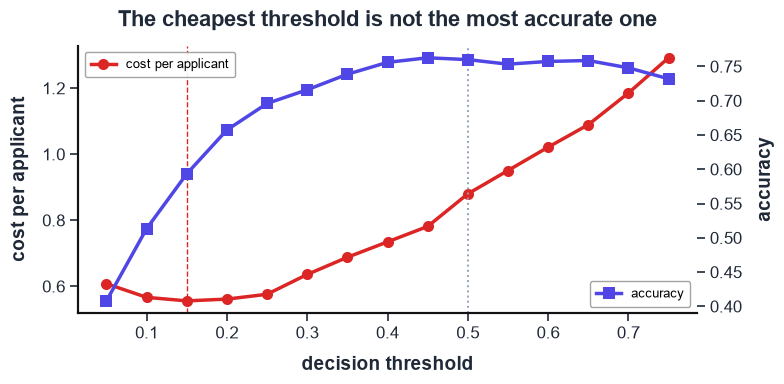

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, costs / len(y_train), marker="o", color="#dc2626", label="cost per applicant")
ax.axvline(chosen, color="#dc2626", linestyle="--", linewidth=1)
ax.axvline(0.5, color="#94a3b8", linestyle=":", linewidth=1.4)
ax.set_xlabel("decision threshold")
ax.set_ylabel("cost per applicant")

twin = ax.twinx()
twin.plot(thresholds, accuracies, marker="s", color="#4f46e5", label="accuracy")
twin.set_ylabel("accuracy")

ax.set_title("The cheapest threshold is not the most accurate one")
ax.legend(loc="upper left", fontsize=9)
twin.legend(loc="lower right", fontsize=9)
plt.show()

Read the two curves against each other.

Accuracy peaks somewhere near the default 0.5 — which is exactly what accuracy is built to do, since it weights the two errors equally and the classes are 70/30.

Cost is minimised far to the left. At a low threshold the bank refuses a lot of applicants it need not have, collecting many cheap errors in order to avoid the expensive ones.

**The accuracy-optimal model and the cost-optimal model are different models,** and the gap between them is not small. If you had optimised accuracy — the default in every library, and the first thing an agent will report — you would have shipped the expensive one.

## 14.7 The test set, once

Every decision is now made: logistic regression, standardised inputs, threshold chosen from out-of-fold probabilities on the training half. Nothing above has seen `X_test`.

In [9]:
final = Workflow([StandardScaler(), LogisticRegression()])
final.fit(X_train, y_train)

test_probabilities = final.predict_proba(X_test)[:, 1]

print(f"{'policy':>18s} {'threshold':>10s} {'cost':>6s} {'per applicant':>14s} "
      f"{'accuracy':>9s} {'defaults missed':>16s}")
print("-" * 80)

for label, threshold in [("default", 0.5), ("cost-optimal", chosen)]:
    predicted = (test_probabilities >= threshold).astype(int)
    matrix = confusion_matrix(y_test, predicted)
    cost = COST_FALSE_NEGATIVE * matrix[1, 0] + COST_FALSE_POSITIVE * matrix[0, 1]
    print(f"{label:>18s} {threshold:10.2f} {cost:6d} {cost / len(y_test):14.3f} "
          f"{accuracy_score(y_test, predicted):9.3f} {matrix[1, 0]:16d}")

            policy  threshold   cost  per applicant  accuracy  defaults missed
--------------------------------------------------------------------------------
           default       0.50    223          0.892     0.764               41
      cost-optimal       0.15    146          0.584     0.576               10


On data neither the model nor the threshold has ever seen, the chosen policy is substantially cheaper than the default — while being **much less accurate**.

That is the book in one table. A model selected by accuracy looks better, reports better, and would have cost this bank considerably more money. The metric was the decision; the algorithm barely mattered.

Compare against the do-nothing baseline to see what the exercise was actually worth:

In [10]:
approve_everyone = COST_FALSE_NEGATIVE * int((y_test == 1).sum())
best_cost = COST_FALSE_NEGATIVE * confusion_matrix(
    y_test, (test_probabilities >= chosen).astype(int))[1, 0] + \
    COST_FALSE_POSITIVE * confusion_matrix(
        y_test, (test_probabilities >= chosen).astype(int))[0, 1]

print(f"approve everyone (ZeroRule): {approve_everyone:4d}")
print(f"our policy                 : {best_cost:4d}")
print(f"saving                     : {1 - best_cost / approve_everyone:.1%}")

approve everyone (ZeroRule):  375
our policy                 :  146
saving                     : 61.1%


## 14.8 Shipping it

The whole analysis as a spec (chapter 9), and the fitted pipeline behind an endpoint (chapter 13):

In [11]:
production = tuiml.train({
    "model": {"name": "LogisticRegression"},
    "data": "credit-g",
    "pipeline": [{"name": "StandardScaler"}],
    "evaluation": {"cv": 10, "metrics": ["accuracy_score", "recall_score", "precision_score"]},
    "random_seed": 42,
})

for name, value in production.metrics_.items():
    print(f"  {name:34s} {value:.4f}")

  cv_accuracy_score_mean             0.7530
  cv_accuracy_score_std              0.0326
  cv_recall_score_mean               0.4674
  cv_recall_score_std                0.0675
  cv_precision_score_mean            0.6160
  cv_precision_score_std             0.1085


```python
production.save("credit_model.joblib")
tuiml.serve("credit_model.joblib", port=8000)
```

And in the calling application — the threshold lives here, not in the model:

```python
DECISION_THRESHOLD = 0.15      # chosen in 14.6; revisit when costs change

probability = post("/models/credit/predict_proba", {"features": [applicant]})
p_default = probability["probabilities"][0][1]
decision = "refuse" if p_default >= DECISION_THRESHOLD else "approve"
```

Chapter 13's argument, restated with a number attached: that constant is the single most likely thing to change, because it encodes a business decision rather than a fact about the data. If the recovery rate on defaults improves, the 5:1 ratio moves and the threshold moves with it — and none of that should require retraining or redeploying a model.

## 14.9 What we did not do

Being explicit about the gaps, because a case study that presents itself as complete teaches the wrong lesson.

**We did not treat the categoricals properly.** Ordinal codes went straight into a linear model. One-hot encoding them (chapter 3) via `On` (chapter 4) is the obvious next experiment.

**We did not tune.** Chapter 7's grid search would likely find a little more, and would need nested CV to report honestly.

**We did not check fairness.** This dataset contains `personal_status`, `age` and `foreign_worker`. A credit model that refuses applicants on those grounds is a legal problem before it is a statistical one, and nothing in this book measured it.

**We validated on 1000 rows from 1994 Germany.** The cost matrix is from the same source. Neither is a description of any bank operating today.

**We have no monitoring.** Chapter 13's list applies in full.

## Recap — and the book

The sequence, which transfers to any tabular problem:

1. **Hold out the test set first**, before looking at anything.
2. **Profile** — imbalance, missing values, column types.
3. **Baseline** with `ZeroRuleClassifier` — know what "do nothing" scores.
4. **Bake-off** across families on identical folds; expect the gaps to be within noise.
5. **Ask what the errors cost**, and pick the metric from the answer, not from the default.
6. **Choose the threshold on out-of-fold predictions**, never on the test set.
7. **Touch the test set once**, at the end.
8. **Ship the pipeline**, and keep the policy constant outside the model.

If there is one idea to carry out of this book, it is the one section 14.7 priced: **the metric you optimise is a bigger decision than the algorithm you choose.** Fourteen chapters of technique came second to a sentence about what a mistake costs.

Where to go from here: revisit chapter 8's checklist before you publish a comparison, chapter 11's before you accept a result an agent produced, and chapter 13's before you let anyone depend on an endpoint.